# Análise de diárias e faturamento por unidade

#Pergunta 1: A diretoria quer entender o comportamento das diárias praticadas na rede e a distribuição do faturamento entre as unidades. O que os dados revelam?

#Importação dos dados

In [124]:
import pandas as pd

df_reservas = pd.read_csv('df_reserva_clean.csv', sep=';')
df_tipos_quarto = pd.read_csv('df_tipos_quarto_clean_1.csv', sep=';')
df_unidades = pd.read_csv('df_unidades_clean.csv', sep=';')

#Separando reservas válidas (que geraram receitam)

In [125]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Juntando reservas com o tipo de quarto 

In [126]:
df_reservas_valor = df_reservas_validas.merge(df_tipos_quarto, on="id_tipo_quarto")
df_reservas_valor.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,descricao,capacidade_max,valor_diaria_base
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,Standard,2,280.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,Standard,2,280.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,Suite,4,950.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,Standard,2,280.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,Deluxe,3,580.0


#Faturamento de cada reserva (valor da diária x nº de dias de hospedagem)

In [127]:
df_reservas_valor['faturamento_reserva'] = df_reservas_valor['valor_diaria_base'] * df_reservas_valor['qtd_diarias']
df_reservas_valor.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,descricao,capacidade_max,valor_diaria_base,faturamento_reserva
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,Standard,2,280.0,560.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,Standard,2,280.0,840.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,Suite,4,950.0,4750.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,Standard,2,280.0,1960.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,Deluxe,3,580.0,2900.0


#Incluindo nome da unidade na tabela de reservas_valor

In [128]:
df_reservas_valor_unidades= df_reservas_valor.merge(df_unidades, on="id_unidade")
df_reservas_valor_unidades.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,...,forma_pagamento,descricao,capacidade_max,valor_diaria_base,faturamento_reserva,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,...,Cartão de Crédito,Standard,2,280.0,560.0,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,...,PIX,Standard,2,280.0,840.0,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,...,Cartão de Crédito,Suite,4,950.0,4750.0,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,65
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,...,Transferência,Standard,2,280.0,1960.0,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,70
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,...,Transferência,Deluxe,3,580.0,2900.0,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45


#Comportamento das diárias

In [129]:
media = df_reservas_valor["valor_diaria_base"].mean()
mediana = df_reservas_valor["valor_diaria_base"].median()
variancia = df_reservas_valor["valor_diaria_base"].var()
desvio_padrao = df_reservas_valor["valor_diaria_base"].std()
coef_var = desvio_padrao / media 
distancia = (media - mediana) / mediana

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Variância: {variancia:.2f}")
print(f"Desvio padrão: {desvio_padrao:.2f}")
print(f"Coeficiente de variação: {coef_var:.2%}")
print(f"Distância entre média e mediana: {distancia:.2%}")

Média: 555.88
Mediana: 420.00
Variância: 104132.11
Desvio padrão: 322.70
Coeficiente de variação: 58.05%
Distância entre média e mediana: 32.35%


#Faturamento por unidade NaraHoteis

In [130]:
df_faturamento_unidades = df_reservas_valor_unidades.groupby('nome_unidade')['faturamento_reserva'].sum().reset_index()
df_faturamento_unidades['percentual'] = (df_faturamento_unidades['faturamento_reserva'] / df_faturamento_unidades['faturamento_reserva'].sum()) * 100
df_faturamento_unidades

,nome_unidade,faturamento_reserva,percentual
0,NaraHoteis Angra dos Reis,368930.0,9.127164
1,NaraHoteis Barra da Tijuca,379930.0,9.399299
2,NaraHoteis Centro,161570.0,3.997170
3,NaraHoteis Friburgo,382230.0,9.456200
4,NaraHoteis Ipanema,316990.0,7.842191
5,NaraHoteis Mangaratiba,357290.0,8.839195
6,NaraHoteis Nova Iguaçu Centro,137630.0,3.404905
7,NaraHoteis Nova Iguaçu Park,375600.0,9.292177
8,NaraHoteis Paraty,415900.0,10.289181
9,NaraHoteis Petrópolis,356430.0,8.817919


In [131]:
print(df_faturamento_unidades.sort_values(by="faturamento_reserva", ascending=False))

                     nome_unidade  faturamento_reserva  percentual
8               NaraHoteis Paraty             415900.0   10.289181
10        NaraHoteis Santa Teresa             406000.0   10.044259
11         NaraHoteis Teresópolis             383610.0    9.490340
3             NaraHoteis Friburgo             382230.0    9.456200
1      NaraHoteis Barra da Tijuca             379930.0    9.399299
7     NaraHoteis Nova Iguaçu Park             375600.0    9.292177
0       NaraHoteis Angra dos Reis             368930.0    9.127164
5          NaraHoteis Mangaratiba             357290.0    8.839195
9           NaraHoteis Petrópolis             356430.0    8.817919
4              NaraHoteis Ipanema             316990.0    7.842191
2               NaraHoteis Centro             161570.0    3.997170
6   NaraHoteis Nova Iguaçu Centro             137630.0    3.404905


Conclusão

#Pergunta 1: A diretoria quer entender o comportamento das diárias praticadas na rede e a distribuição do faturamento entre as unidades. O que os
dados revelam? 

R:Os dados mostram que as diárias têm muita variação, com média em torno de R$ 560 e mediana de R$ 580, indicando preços de diárias bem diferentes entre os hotéis. O faturamento está distribuído de forma relativamente equilibrada entre as principais unidades: Paraty, Friburgo, Santa Teresa, Teresópolis e Petrópolis concentram cerca de metade da receita total, enquanto unidades como Centro e Nova Iguaçu Centro têm participação bem menor. 

# Painel Matplotlib

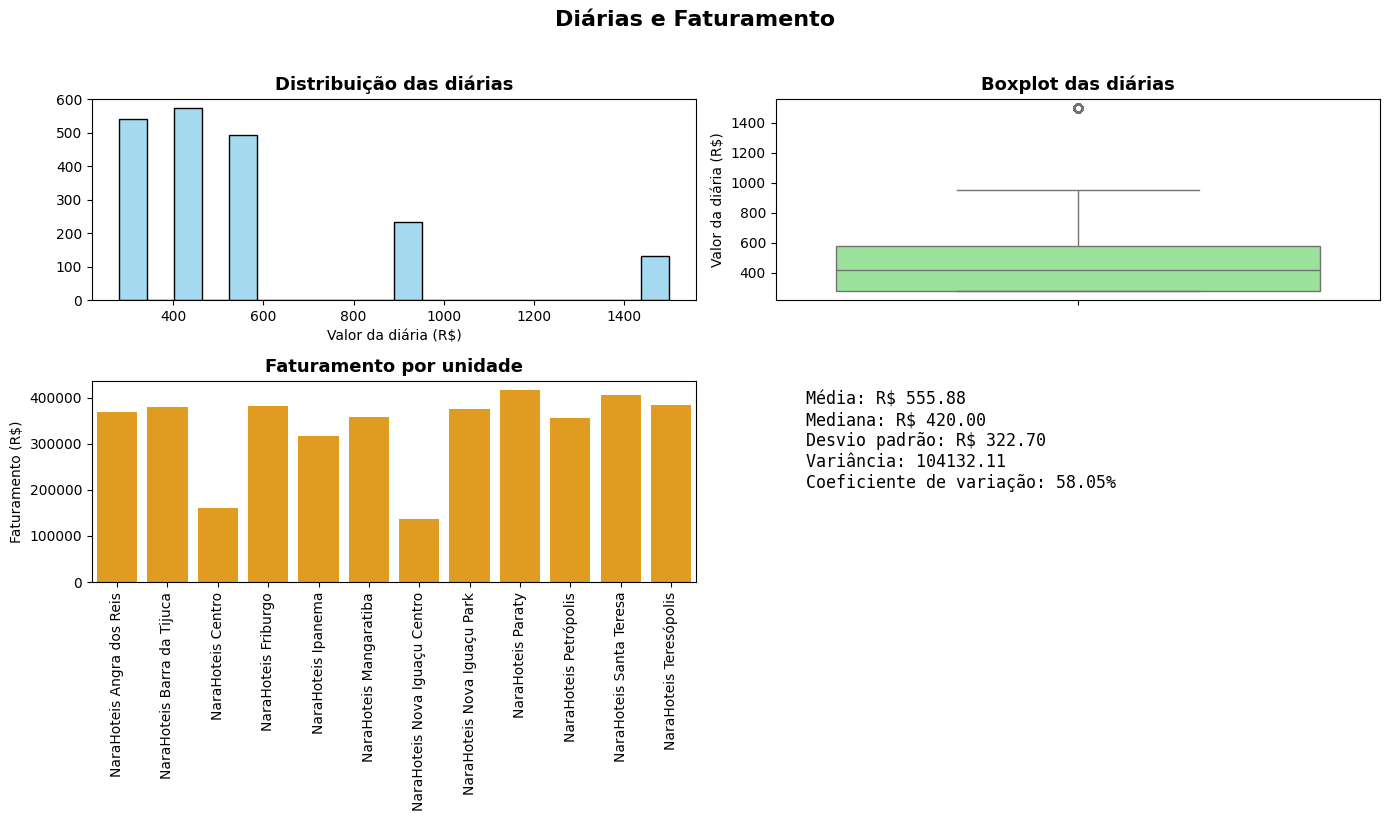

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# 1 - Histograma das diárias
sns.histplot(df_reservas_valor["valor_diaria_base"], bins=20, ax=axs[0,0], color="skyblue")
axs[0,0].set_title("Distribuição das diárias", fontsize=13, fontweight="bold")
axs[0,0].set_xlabel("Valor da diária (R$)")
axs[0,0].set_ylabel("")

# 2 - Boxplot das diárias
sns.boxplot(y=df_reservas_valor["valor_diaria_base"], ax=axs[0,1], color="lightgreen")
axs[0,1].set_title("Boxplot das diárias", fontsize=13, fontweight="bold")
axs[0,1].set_ylabel("Valor da diária (R$)")

# 3 - Faturamento por unidade (barras)
sns.barplot(x=df_faturamento_unidades["nome_unidade"], y=df_faturamento_unidades["faturamento_reserva"], ax=axs[1,0], color="orange")
axs[1,0].set_title("Faturamento por unidade", fontsize=13, fontweight="bold")
axs[1,0].set_xlabel("")
axs[1,0].set_ylabel("Faturamento (R$)")
axs[1,0].tick_params(axis="x", rotation=90)

# 4 - Métricas resumo com plt.text()
media = df_reservas_valor["valor_diaria_base"].mean()
mediana = df_reservas_valor["valor_diaria_base"].median()
desvio = df_reservas_valor["valor_diaria_base"].std()
variancia = df_reservas_valor["valor_diaria_base"].var()
coef_var = desvio / media

axs[1,1].axis("off")
texto = (
    f"Média: R$ {media:.2f}\n"
    f"Mediana: R$ {mediana:.2f}\n"
    f"Desvio padrão: R$ {desvio:.2f}\n"
    f"Variância: {variancia:.2f}\n"
    f"Coeficiente de variação: {coef_var:.2%}"
)
axs[1,1].text(0.05, 0.95, texto,
              transform=axs[1,1].transAxes,
              fontsize=12, verticalalignment="top",
              fontfamily="monospace")

# Título geral
fig.suptitle("Diárias e Faturamento", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

Comentário:

Esse painel mostra como estão as diárias e o faturamento das unidades da rede Nara Hotéis.

O histograma ajuda a ver que os preços das diárias variam bastante.As diárias têm variação, com média em torno de R$ 560 e mediana de R$ 580, indicando preços bem diferentes entre os hotéis.

O boxplot confirma essa variação e mostra que existem alguns valores bem acima da média (outliers).

O gráfico de barras mostra o faturamento de cada unidade, deixando claro que as unidades que concentram mais faturamento são Paraty, Friburgo, Santa Teresa, Teresópolis e Petrópolis.

O quadro de métricas resume os números principais (média, mediana, desvio, variância e coeficiente de variação), facilitando a leitura do comportamento das diárias.

Com isso, dá pra concluir que as diárias têm muita diferença entre os hotéis e que o faturamento está mais concentrado em algumas unidades, como Paraty, Friburgo, Santa Teresa, Teresópolis e Petrópolis.

# Análise de unidades operando fora da capacidade 

#Pergunta 2: Existem unidades operando além de sua capacidade? Quais o impactos disso para o negócio?

#Importação dos dados

In [133]:
import pandas as pd
df_reservas = pd.read_csv( 'df_reserva_clean.csv', sep=';')
df_unidades = pd.read_csv( 'df_unidades_clean.csv' , sep=';')

#Filtrando reservas válidas

In [134]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Período das reservas

In [135]:
data_inicio_reserva = pd.to_datetime(df_reservas_validas['data_checkin']).min()
data_fim_reserva = pd.to_datetime(df_reservas_validas['data_checkout']).max()
periodo = (data_fim_reserva - data_inicio_reserva).days
print("Data início:", data_inicio_reserva)
print("Data fim:", data_fim_reserva)
print("Período em dias:", periodo)

Data início: 2023-01-01 00:00:00
Data fim: 2025-01-06 00:00:00
Período em dias: 736


#Contando o nº de reservas por dia

In [136]:
df_reservas_por_dia = df_reservas_validas.groupby(['id_unidade', 'data_checkin']).size().reset_index()
df_reservas_por_dia.columns = ['id_unidade', 'data_checkin', 'reservas_no_dia']
df_reservas_por_dia.head()

,id_unidade,data_checkin,reservas_no_dia
0,1,2023-01-05,1
1,1,2023-01-10,1
2,1,2023-01-13,1
3,1,2023-01-15,1
4,1,2023-01-23,1


#Capacidade dos hotéis: o número de quartos fazendo o merge com a tabela de unidades

In [137]:
df_capacidade_unidades = df_reservas_por_dia.merge(df_unidades[['id_unidade','nome_unidade','num_quartos_total']], on='id_unidade')
df_capacidade_unidades.head()

,id_unidade,data_checkin,reservas_no_dia,nome_unidade,num_quartos_total
0,1,2023-01-05,1,NaraHoteis Ipanema,80
1,1,2023-01-10,1,NaraHoteis Ipanema,80
2,1,2023-01-13,1,NaraHoteis Ipanema,80
3,1,2023-01-15,1,NaraHoteis Ipanema,80
4,1,2023-01-23,1,NaraHoteis Ipanema,80


#Verificando se o nº de reservas/check ins no dia é superior ao nº de quartos da unidade para identificar se há overbooking.

In [138]:
df_unidades_com_overbooking = df_capacidade_unidades[df_capacidade_unidades['reservas_no_dia'] > df_capacidade_unidades['num_quartos_total']]
df_unidades_com_overbooking.head()

,id_unidade,data_checkin,reservas_no_dia,nome_unidade,num_quartos_total
275,3,2023-07-15,74,NaraHoteis Centro,60
289,3,2024-01-15,79,NaraHoteis Centro,60
503,5,2023-10-15,62,NaraHoteis Nova Iguaçu Centro,50
528,5,2024-06-15,64,NaraHoteis Nova Iguaçu Centro,50


Conclusão

#Pergunta 2: Existem unidades operando além de sua capacidade? Quais os impactos disso para o negócio?

R:Sim, existem unidades operando além da capacidade. Encontramos 4 datas em que o número de pessoas chegando para entrar no hotel foi maior do que a quantidade de quartos que o hotel possui: o NaraHoteis Centro estourou a capacidade duas vezes (em 15/07/2023 com 74 reservas e em 15/01/2024 com 79 reservas, sendo que ele só tem 60 quartos).O NaraHoteis Nova Iguaçu Centro também estourou duas vezes (em 15/10/2023 com 62 reservas e em 15/06/2024 com 64 reservas, para um total de 50 quartos).
Impactos para o negócio são overbooking real, reembolso do valor pago pela reserva que não pode ser honrada,clientes insatisfeitos,além de sobrecarga da equipe do hotel.

# Análise de performance de receita por unidade

#Pergunta 3: Existem unidades com performance de receita discrepante em relação às demais? Como você identificaria, mediria e comprovaria isso?

#Importação dos dados

In [139]:
import pandas as pd
import numpy as np

df_reservas = pd.read_csv("df_reserva_clean.csv", sep=";")
df_unidades = pd.read_csv("df_unidades_clean.csv", sep=";")
df_quartos = pd.read_csv("df_tipos_quarto_clean_1.csv", sep=";")

#Filtrando as reservas válidas

In [140]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Valor da diária pelo tipo do quarto 

In [141]:
df_reservas_validas = df_reservas_validas.merge(df_quartos[['id_tipo_quarto','valor_diaria_base','descricao']],on='id_tipo_quarto')
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,280.0,Standard
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,280.0,Standard
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,950.0,Suite
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,280.0,Standard
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,580.0,Deluxe


#Receita de cada reserva


In [142]:
df_reservas_validas['receita'] = df_reservas_validas['qtd_diarias'] * df_reservas_validas['valor_diaria_base']
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao,receita
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,280.0,Standard,560.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,280.0,Standard,840.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,950.0,Suite,4750.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,280.0,Standard,1960.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,580.0,Deluxe,2900.0


#Total de receita por unidade

In [143]:
df_receita_unidade = df_reservas_validas.groupby(['id_unidade'])['receita'].sum().reset_index()
df_receita_unidade

,id_unidade,receita
0,1,316990.0
1,2,379930.0
2,3,161570.0
3,4,406000.0
4,5,137630.0
5,6,375600.0
6,7,356430.0
7,8,383610.0
8,9,382230.0
9,10,415900.0


#Total de receita por Unidade

In [144]:
df_receita_unidade = df_receita_unidade.merge(df_unidades[['id_unidade','nome_unidade',]], on='id_unidade')
df_receita_unidade.head()

,id_unidade,receita,nome_unidade
0,1,316990.0,NaraHoteis Ipanema
1,2,379930.0,NaraHoteis Barra da Tijuca
2,3,161570.0,NaraHoteis Centro
3,4,406000.0,NaraHoteis Santa Teresa
4,5,137630.0,NaraHoteis Nova Iguaçu Centro


#Verificando Outliers

In [146]:
array_df_receita_unidade=np.array(df_receita_unidade['receita'])

Q1 = np.percentile(array_df_receita_unidade, 25)
Q3 = np.percentile(array_df_receita_unidade, 75)
IQR = Q3 - Q1
limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Q1: 346570.0
Q3: 382575.0
IQR: 36005.0
Limite inferior: 292562.5
Limite superior: 436582.5


#Demarcando outliers

In [147]:
df_receita_unidade['outlier'] = (df_receita_unidade['receita'] < limite_inferior) | (df_receita_unidade['receita'] > limite_superior)
df_receita_unidade

,id_unidade,receita,nome_unidade,outlier
0,1,316990.0,NaraHoteis Ipanema,False
1,2,379930.0,NaraHoteis Barra da Tijuca,False
2,3,161570.0,NaraHoteis Centro,True
3,4,406000.0,NaraHoteis Santa Teresa,False
4,5,137630.0,NaraHoteis Nova Iguaçu Centro,True
5,6,375600.0,NaraHoteis Nova Iguaçu Park,False
6,7,356430.0,NaraHoteis Petrópolis,False
7,8,383610.0,NaraHoteis Teresópolis,False
8,9,382230.0,NaraHoteis Friburgo,False
9,10,415900.0,NaraHoteis Paraty,False


In [148]:
print(df_receita_unidade)

    id_unidade   receita                   nome_unidade  outlier
0            1  316990.0             NaraHoteis Ipanema    False
1            2  379930.0     NaraHoteis Barra da Tijuca    False
2            3  161570.0              NaraHoteis Centro     True
3            4  406000.0        NaraHoteis Santa Teresa    False
4            5  137630.0  NaraHoteis Nova Iguaçu Centro     True
5            6  375600.0    NaraHoteis Nova Iguaçu Park    False
6            7  356430.0          NaraHoteis Petrópolis    False
7            8  383610.0         NaraHoteis Teresópolis    False
8            9  382230.0            NaraHoteis Friburgo    False
9           10  415900.0              NaraHoteis Paraty    False
10          11  368930.0      NaraHoteis Angra dos Reis    False
11          12  357290.0         NaraHoteis Mangaratiba    False


Conclusão

#Pergunta 3: Existem unidades com performance de receita discrepante em relação às demais? Como você identificaria, mediria e comprovaria isso?

Sim. As unidades NaraHoteis Centro e NaraHoteis Nova Iguaçu Centro tem receita discrepante e inferior em relação às demais.Identificamos isso calculando o IQR e destacando os outliers.

# Análise entre RevPAR das unidades e a avaliação média dos hóspedes

#Pergunta 4: Há relação entre o RevPAR das unidades e a avaliação média dos hóspedes? Essa relação é forte o suficiente para sustentar uma análise
preditiva?

#Importação dos dados

In [149]:
import pandas as pd
import numpy as np

df_reservas = pd.read_csv("df_reserva_clean.csv", sep=";")
df_unidades = pd.read_csv("df_unidades_clean.csv", sep=";")
df_quartos = pd.read_csv("df_tipos_quarto_clean_1.csv", sep=";")

#Filtrando apenas as reservas válidas

In [150]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Valor da diária das reservas válidas

In [151]:
df_reservas_validas = df_reservas_validas.merge(df_quartos[['id_tipo_quarto','valor_diaria_base','descricao']], on='id_tipo_quarto')
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,280.0,Standard
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,280.0,Standard
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,950.0,Suite
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,280.0,Standard
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,580.0,Deluxe


#Corrigindo o valor_diaria_base para número

In [152]:
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].astype(str)
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].str.replace('R$','')
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].str.replace('.','')
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].str.replace(',','.')
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].astype(float)
df_reservas_validas['qtd_diarias'] = pd.to_numeric(df_reservas_validas['qtd_diarias'], errors='coerce')
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,2800.0,Standard
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,2800.0,Standard
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,9500.0,Suite
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,2800.0,Standard
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,5800.0,Deluxe


#Valor total de cada reserva

In [153]:
df_reservas_validas['valor_total_reserva'] = df_reservas_validas['qtd_diarias'] * df_reservas_validas['valor_diaria_base']
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao,valor_total_reserva
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,2800.0,Standard,5600.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,2800.0,Standard,8400.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,9500.0,Suite,47500.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,2800.0,Standard,19600.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,5800.0,Deluxe,29000.0


#Juntando reservas com unidades para trazer o nome_unidade

In [154]:
df_reservas = df_reservas_validas.merge(df_unidades[['id_unidade','nome_unidade']], on='id_unidade')
df_reservas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao,valor_total_reserva,nome_unidade
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,2800.0,Standard,5600.0,NaraHoteis Nova Iguaçu Centro
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,2800.0,Standard,8400.0,NaraHoteis Nova Iguaçu Centro
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,9500.0,Suite,47500.0,NaraHoteis Paraty
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,2800.0,Standard,19600.0,NaraHoteis Petrópolis
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,5800.0,Deluxe,29000.0,NaraHoteis Santa Teresa


#Receita de cada unidade

In [155]:
df_receita_unidade = df_reservas.groupby(['id_unidade','nome_unidade'])['valor_total_reserva'].sum().reset_index()
df_receita_unidade = df_receita_unidade.rename(columns={'valor_total_reserva': 'receita_total'})
df_receita_unidade.head()

,id_unidade,nome_unidade,receita_total
0,1,NaraHoteis Ipanema,3169900.0
1,2,NaraHoteis Barra da Tijuca,3799300.0
2,3,NaraHoteis Centro,1615700.0
3,4,NaraHoteis Santa Teresa,4060000.0
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0


#Avaliação média por unidade

In [156]:
df_avaliacao_unidade = df_reservas.groupby('nome_unidade')['avaliacao_hospede'].mean().reset_index(name="avaliacao_hospede_media")
df_avaliacao_unidade

,nome_unidade,avaliacao_hospede_media
0,NaraHoteis Angra dos Reis,7.875969
1,NaraHoteis Barra da Tijuca,7.880952
2,NaraHoteis Centro,2.101852
3,NaraHoteis Friburgo,8.060606
4,NaraHoteis Ipanema,8.116667
5,NaraHoteis Mangaratiba,7.750000
6,NaraHoteis Nova Iguaçu Centro,2.104396
7,NaraHoteis Nova Iguaçu Park,7.938931
8,NaraHoteis Paraty,7.909774
9,NaraHoteis Petrópolis,7.984615


#Lado a lado: receita de cada unidade vs avaliação média dos hóspedes

In [157]:
df_unidade_linear = df_receita_unidade.merge(df_avaliacao_unidade, on='nome_unidade')
df_unidade_linear

,id_unidade,nome_unidade,receita_total,avaliacao_hospede_media
0,1,NaraHoteis Ipanema,3169900.0,8.116667
1,2,NaraHoteis Barra da Tijuca,3799300.0,7.880952
2,3,NaraHoteis Centro,1615700.0,2.101852
3,4,NaraHoteis Santa Teresa,4060000.0,8.150943
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,2.104396
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,7.938931
6,7,NaraHoteis Petrópolis,3564300.0,7.984615
7,8,NaraHoteis Teresópolis,3836100.0,8.145299
8,9,NaraHoteis Friburgo,3822300.0,8.060606
9,10,NaraHoteis Paraty,4159000.0,7.909774


In [163]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total
0,1,NaraHoteis Ipanema,3169900.0
1,2,NaraHoteis Barra da Tijuca,3799300.0
2,3,NaraHoteis Centro,1615700.0
3,4,NaraHoteis Santa Teresa,4060000.0
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0
5,6,NaraHoteis Nova Iguaçu Park,3756000.0
6,7,NaraHoteis Petrópolis,3564300.0
7,8,NaraHoteis Teresópolis,3836100.0
8,9,NaraHoteis Friburgo,3822300.0
9,10,NaraHoteis Paraty,4159000.0


#Juntando com o número de quartos

In [ ]:
##df_unidades = df_unidades.merge(df_unidades[['num_quartos_total', 'nome_unidade']], on='nome_unidade')
####df_unidade.head()

NameError: name 'df_unidade' is not defined

In [111]:
df_unidades

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total_x,num_quartos_total_y
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 estrelas,120,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 estrelas,60,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 estrelas,55,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,70,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 estrelas,60,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 estrelas,55,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,65,65


#RevPAR

In [176]:
periodo=365
df_receita_unidade['RevPAR'] = df_receita_unidade['receita_total'] / (df_unidades['num_quartos_total'] * periodo)
df_unidades.head()


,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 estrelas,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 estrelas,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50


In [178]:
df_unidade_linear

,id_unidade,nome_unidade,receita_total,avaliacao_hospede_media
0,1,NaraHoteis Ipanema,3169900.0,8.116667
1,2,NaraHoteis Barra da Tijuca,3799300.0,7.880952
2,3,NaraHoteis Centro,1615700.0,2.101852
3,4,NaraHoteis Santa Teresa,4060000.0,8.150943
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,2.104396
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,7.938931
6,7,NaraHoteis Petrópolis,3564300.0,7.984615
7,8,NaraHoteis Teresópolis,3836100.0,8.145299
8,9,NaraHoteis Friburgo,3822300.0,8.060606
9,10,NaraHoteis Paraty,4159000.0,7.909774


#Covariância entre RevPAR e avaliação média dos hóspedes

In [179]:
matriz_cov_revpar_avaliacao= np.cov(df_receita_unidade['RevPAR'], df_unidade_linear['avaliacao_hospede_media'])
print(matriz_cov_revpar_avaliacao)

# Extraindo só o valor da covariância
cov_valor = matriz_cov_revpar_avaliacao[0, 1]
print(f"Covariância: {cov_valor:.2f}")

[[3123.23568149   78.99123107]
 [  78.99123107    5.25014751]]
Covariância: 78.99


#Analisando a correlação entre RevPAR e a avaliação média dos hóspedes

In [ ]:
correlacao_revpar_avaliacao_media_hospedes = np.corrcoef(df_unidade['RevPAR'], df_unidade['avaliacao_hospede_media'])
print(f"Pearson r = {correlacao_revpar_avaliacao_media_hospedes[0,1]:.4f}")

Pearson r = 0.6169


Conclusão

#Pergunta 4: Há relação entre o RevPAR das unidades e a avaliação média dos hóspedes? Essa relação é forte o suficiente para sustentar uma análise preditiva?

R: Há correlação moderada positiva entre RevPAR e avaliação média dos hóspedes (correlação = 0,68). A correlação permite sustentar uma análise preditiva.

# Análise preditiva RevPAR a partir da avaliação média dos hóspedes

#Pergunta 5: Com base nos dados históricos, é possível estimar o RevPAR esperado de uma unidade a partir da sua avaliação média? Construa e avalie esse modelo. 

#Importando dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x=df_unidade[['avaliacao_hospede_media']]
y=df_unidade['RevPAR']



#Modelo preditivo

In [ ]:
modelo = LinearRegression()
modelo.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[15.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['avaliacao_hospede_media']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [ ]:
x_extendido = pd.DataFrame({'avaliacao_hospede_media':[9, 9.2,9.5,10]})
y_tend = modelo.predict(x_extendido)

#Visualização de resultados

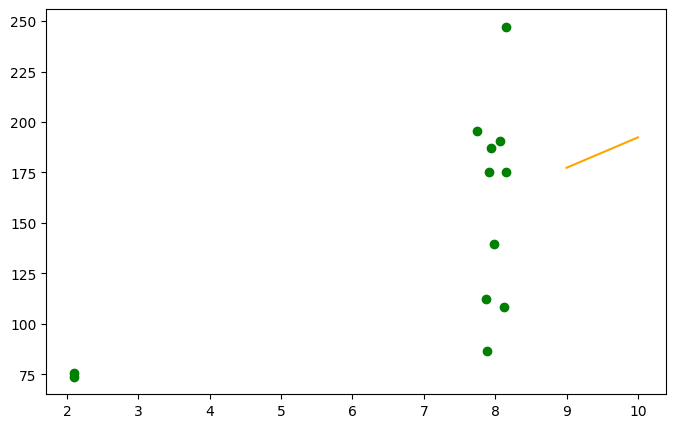

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
df_unidade['avaliacao_hospede_media'],
df_unidade['RevPAR'],
color='green',
label='Dados reais'
)
plt.plot(
x_extendido['avaliacao_hospede_media'],
y_tend,
color='orange',
label='Reta de tendência'
)

Conclusão

#Pergunta 5: Com base nos dados históricos, é possível estimar o RevPAR esperado de uma unidade a partir da sua avaliação média? Construa e avalie esse modelo.

R:Sim, é possível. Foi construído um modelo de regressão linear relacionando a avaliação média dos hóspedes com o RevPAR das unidades. O gráfico mostra uma tendência positiva: quanto maior a avaliação, maior tende a ser o RevPAR. Isso indica que a satisfação dos hóspedes tem impacto na RevPAR.

# Análise de Variabilidade de Faturamento por Região

#Pergunta 6: Qual região apresenta maior variabilidade no faturamento? O que isso pode indicar para a gestão comercial?

In [ ]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total
0,1,NaraHoteis Ipanema,3169900.0
1,2,NaraHoteis Barra da Tijuca,3799300.0
2,3,NaraHoteis Centro,1615700.0
3,4,NaraHoteis Santa Teresa,4060000.0
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0
5,6,NaraHoteis Nova Iguaçu Park,3756000.0
6,7,NaraHoteis Petrópolis,3564300.0
7,8,NaraHoteis Teresópolis,3836100.0
8,9,NaraHoteis Friburgo,3822300.0
9,10,NaraHoteis Paraty,4159000.0


#Exibindo a regiao das unidades e o total de receita de cada uma.

In [171]:


df_receita_regiao = df_receita_unidade.merge(df_unidades[['id_unidade','regiao']], on='id_unidade')
df_receita_regiao.head()

,id_unidade,nome_unidade,receita_total,RevPAR,regiao
0,1,NaraHoteis Ipanema,3169900.0,108.558219,Capital
1,2,NaraHoteis Barra da Tijuca,3799300.0,86.742009,Capital
2,3,NaraHoteis Centro,1615700.0,73.776256,Capital
3,4,NaraHoteis Santa Teresa,4060000.0,247.184170,Capital
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,75.413699,Baixada Fluminense


#Analisando variabilidade por região

In [99]:
#Capital
capital = df_receita_regiao[df_receita_regiao["regiao"] == "Capital"]["receita_total"]
media_capital = np.mean(capital)
desvio_capital = np.std(capital)
print("Região: Capital")
print(f"Média da receita: {media_capital:.2f}")
print(f"Desvio padrão: {desvio_capital:.2f}")
print(f"Faixa típica: {media_capital-desvio_capital:.2f} até {media_capital+desvio_capital:.2f}\n")

#Baixada Fluminense
baixada = df_receita_regiao[df_receita_regiao["regiao"] == "Baixada Fluminense"]["receita_total"]
media_baixada = np.mean(baixada)
desvio_baixada = np.std(baixada)
print("Região: Baixada Fluminense")
print(f"Média da receita: {media_baixada:.2f}")
print(f"Desvio padrão: {desvio_baixada:.2f}")
print(f"Faixa típica: {media_baixada-desvio_baixada:.2f} até {media_baixada+desvio_baixada:.2f}\n")

#Serra
serra = df_receita_regiao[df_receita_regiao["regiao"] == "Serra"]["receita_total"]
media_serra = np.mean(serra)
desvio_serra = np.std(serra)
print("Região: Serra")
print(f"Média da receita: {media_serra:.2f}")
print(f"Desvio padrão: {desvio_serra:.2f}")
print(f"Faixa típica: {media_serra-desvio_serra:.2f} até {media_serra+desvio_serra:.2f}\n")

#Costa Verde
costa = df_receita_regiao[df_receita_regiao["regiao"] == "Costa Verde"]["receita_total"]
media_costa = np.mean(costa)
desvio_costa = np.std(costa)
print("Região: Costa Verde")
print(f"Média da receita: {media_costa:.2f}")
print(f"Desvio padrão: {desvio_costa:.2f}")
print(f"Faixa típica: {media_costa-desvio_costa:.2f} até {media_costa+desvio_costa:.2f}\n")

Região: Capital
Média da receita: 3161225.00
Desvio padrão: 949165.29
Faixa típica: 2212059.71 até 4110390.29

Região: Baixada Fluminense
Média da receita: 2566150.00
Desvio padrão: 1189850.00
Faixa típica: 1376300.00 até 3756000.00

Região: Serra
Média da receita: 3740900.00
Desvio padrão: 125002.08
Faixa típica: 3615897.92 até 3865902.08

Região: Costa Verde
Média da receita: 3807066.67
Desvio padrão: 253350.93
Faixa típica: 3553715.73 até 4060417.60



Conclusão

#Pergunta 6: Qual região apresenta maior variabilidade no faturamento? O que isso pode indicar para a gestão comercial?

A região com maior variabilidade no faturamento é a Baixada Fluminense, seguida pela Capital. Isso acontece porque as unidades dessas regiões têm receitas bem diferentes entre si. Isso indica que essas regiões são mais desiguais e precisam de mais atenção para entender o motivo dessas diferenças.

# Painel Matplotlib

In [98]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total
0,1,NaraHoteis Ipanema,3169900.0
1,2,NaraHoteis Barra da Tijuca,3799300.0
2,3,NaraHoteis Centro,1615700.0
3,4,NaraHoteis Santa Teresa,4060000.0
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0
5,6,NaraHoteis Nova Iguaçu Park,3756000.0
6,7,NaraHoteis Petrópolis,3564300.0
7,8,NaraHoteis Teresópolis,3836100.0
8,9,NaraHoteis Friburgo,3822300.0
9,10,NaraHoteis Paraty,4159000.0


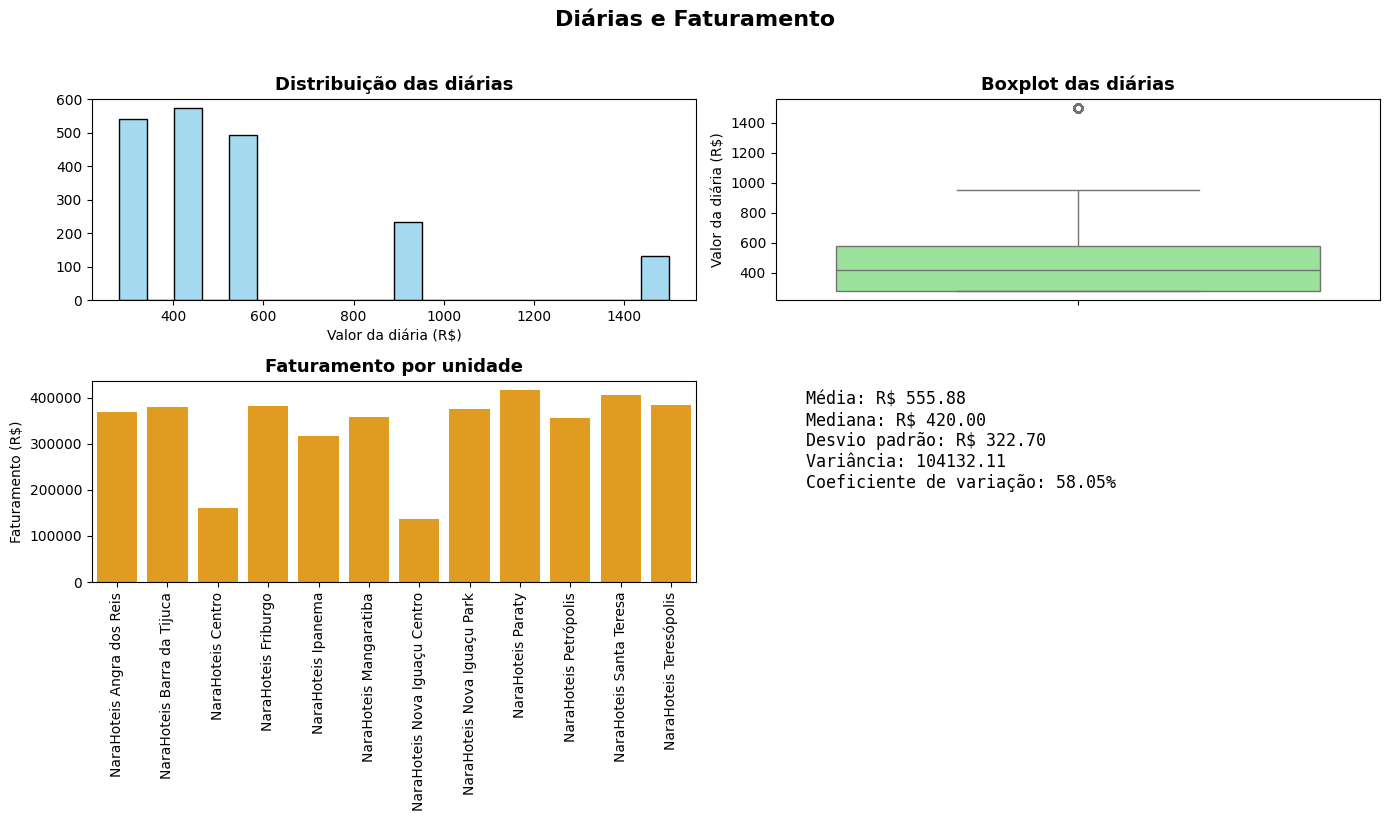

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# 1 - Histograma das diárias
sns.histplot(df_reservas_valor["valor_diaria_base"], bins=20, ax=axs[0,0], color="skyblue")
axs[0,0].set_title("Distribuição das diárias", fontsize=13, fontweight="bold")
axs[0,0].set_xlabel("Valor da diária (R$)")
axs[0,0].set_ylabel("")

# 2 - Boxplot das diárias
sns.boxplot(y=df_reservas_valor["valor_diaria_base"], ax=axs[0,1], color="lightgreen")
axs[0,1].set_title("Boxplot das diárias", fontsize=13, fontweight="bold")
axs[0,1].set_ylabel("Valor da diária (R$)")

# 3 - Faturamento por unidade (barras)
sns.barplot(x="nome_unidade", y="faturamento_reserva", data=df_faturamento_unidades, ax=axs[1,0], color="orange")
axs[1,0].set_title("Faturamento por unidade", fontsize=13, fontweight="bold")
axs[1,0].set_xlabel("")
axs[1,0].set_ylabel("Faturamento (R$)")
axs[1,0].tick_params(axis="x", rotation=90)

# 4 - Métricas resumo com plt.text()
media = df_reservas_valor["valor_diaria_base"].mean()
mediana = df_reservas_valor["valor_diaria_base"].median()
desvio = df_reservas_valor["valor_diaria_base"].std()
variancia = df_reservas_valor["valor_diaria_base"].var()
coef_var = desvio / media

axs[1,1].axis("off")
texto = (
    f"Média: R$ {media:.2f}\n"
    f"Mediana: R$ {mediana:.2f}\n"
    f"Desvio padrão: R$ {desvio:.2f}\n"
    f"Variância: {variancia:.2f}\n"
    f"Coeficiente de variação: {coef_var:.2%}"
)
axs[1,1].text(0.05, 0.95, texto,
              transform=axs[1,1].transAxes,
              fontsize=12, verticalalignment="top",
              fontfamily="monospace")

# Título geral
fig.suptitle("Diárias e Faturamento", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

In [187]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total,RevPAR
0,1,NaraHoteis Ipanema,3169900.0,108.558219
1,2,NaraHoteis Barra da Tijuca,3799300.0,86.742009
2,3,NaraHoteis Centro,1615700.0,73.776256
3,4,NaraHoteis Santa Teresa,4060000.0,247.184170
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,75.413699
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,187.098381
6,7,NaraHoteis Petrópolis,3564300.0,139.502935
7,8,NaraHoteis Teresópolis,3836100.0,175.164384
8,9,NaraHoteis Friburgo,3822300.0,190.400996
9,10,NaraHoteis Paraty,4159000.0,175.300316


KeyError: 'outlier'

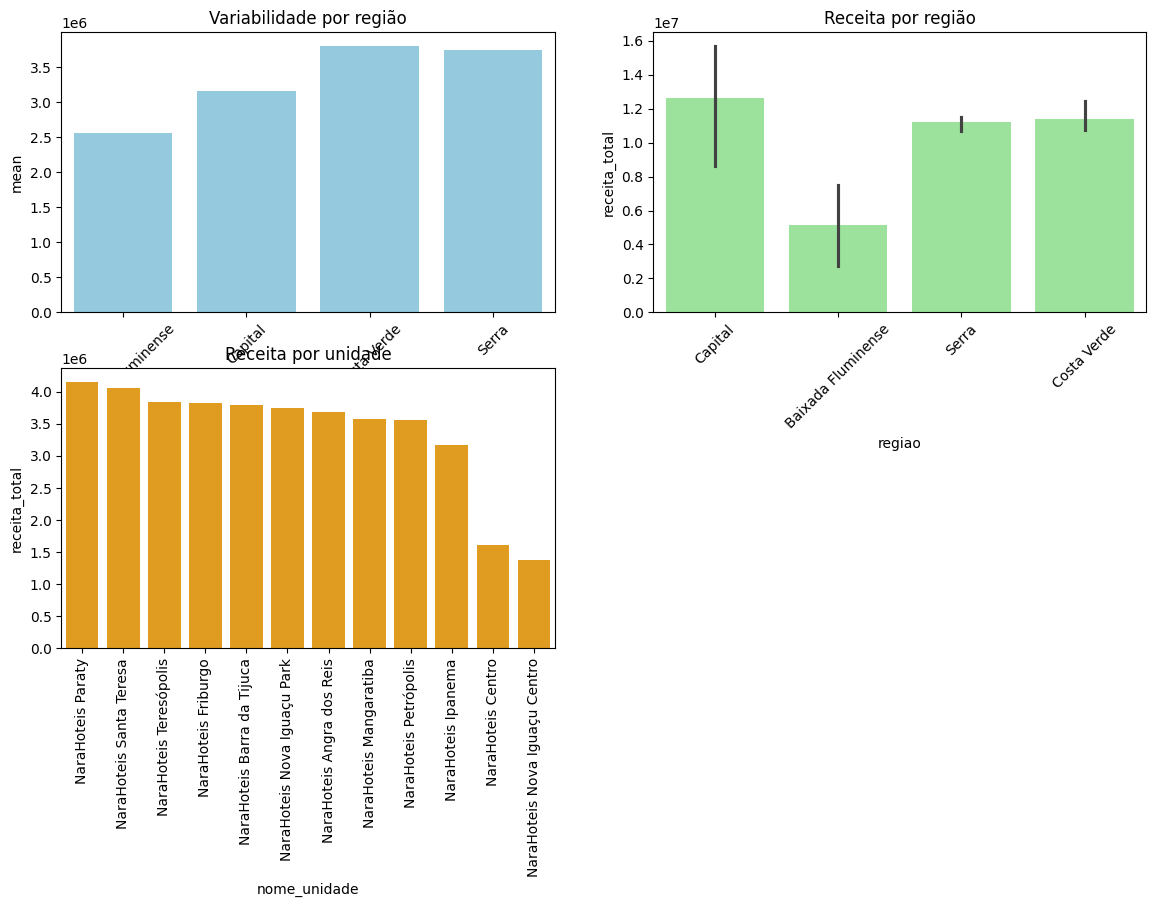

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Variabilidade por região
df_stats_regiao = df_receita_regiao.groupby("regiao")["receita_total"].agg(["mean","std"]).reset_index()

sns.barplot(
    x="regiao", y="mean",
    data=df_stats_regiao,
    ax=axs[0,0],
    color="skyblue"
)

axs[0,0].set_title("Variabilidade por região")
axs[0,0].tick_params(axis="x", rotation=45)

# Receita por região
sns.barplot(
    x="regiao", y="receita_total",
    data=df_receita_regiao,
    ax=axs[0,1],
    color="lightgreen",
    estimator=sum
)

axs[0,1].set_title("Receita por região")
axs[0,1].tick_params(axis="x", rotation=45)

# Receita por unidade
df_ord = df_receita_unidade.sort_values("receita_total", ascending=False)

sns.barplot(
    x="nome_unidade", y="receita_total",
    data=df_ord,
    ax=axs[1,0],
    color="orange"
)

axs[1,0].set_title("Receita por unidade")
axs[1,0].tick_params(axis="x", rotation=90)

# Texto (outliers)
axs[1,1].axis("off")

outliers = df_receita_unidade[
    df_receita_unidade["outlier"] == True
]["nome_unidade"].tolist()

texto = "Outliers:\n" + "\n".join('outlier')

axs[1,1].text(
    0.05, 0.95,
    texto,
    transform=axs[1,1].transAxes,
    fontsize=12,
    verticalalignment='top'
)

# Título geral
fig.suptitle("Painel de Receita", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()




Comentário:

Gráfico 1 — Variabilidade da receita por região:
Esse gráfico mostra que algumas regiões têm muita variação na receita. A região com maior variabilidade no faturamento é a Baixada Fluminense, seguida pela Capital, pois as unidades têm receitas muito diferentes entre si.

Gráfico 2 — Receita total por região:
Neste gráfico é possível identificar as regiões com maior faturamento (Costa Verde,Serra e Capital) e que são importantes para o desempenho da empresa.

Gráfico 3 — Receita por unidade:
Esse gráfico mostra quanto cada unidade gera de faturamento. Dá pra perceber que algumas unidades têm um faturamento bem menor que outras (Centro e Nova Iguaçú Centro), o que mostra diferença de desempenho entre elas.

Gráfico 4 — Outliers:
Nesse quadro destacamos as unidades que estão fora do padrão. Ou seja, unidades que têm receita muito diferente das outras.As unidades NaraHoteis Centro e NaraHoteis Nova Iguaçu Centro tem receita discrepante e inferior em relação às demais.

Conclusão:
No geral, o painel ajuda a entender como está a receita da empresa, mostrando diferenças entre regiões e unidades. Isso ajuda a identificar onde estão os melhores resultados e pontos de melhoria.